# Assignment 1 2AMM10 2025-2026

## Group: [Fill in your group name]
### Member 1: [Fill in your name]
### Member 2: [Fill in your name]
### Member 3: [Fill in your name]

In [57]:
import torch
import json
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random
import numpy as np

## Global Variables ##
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
DATA_DIR = "./data"
DROWSY_DATASET_DIR = Path(
    DATA_DIR, "drowsy_graph_dataset"
)  # Path to the drowsy dataset
OBJ_CLS_DATASET_DIR = Path(
    DATA_DIR, "bdd8cls_balanced_300_30"
)  # Path to the object classification dataset
DEVICE = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else (
        torch.device("mps")
        if torch.backends.mps.is_available()
        else torch.device("cpu")
    )
)

# Task 1

In [58]:
class DrowsyFaceGraphDataset(Dataset):
    def __init__(self, root, split="train"):
        self.root = Path(root)
        self.split = split

        data_path = self.root / f"{split}.pt"
        class_to_id_path = self.root / "class_to_id.json"
        id_to_class_path = self.root / "id_to_class.json"

        if not data_path.exists():
            raise FileNotFoundError(f"Could not find {data_path}")

        self.graphs = torch.load(data_path, weights_only=False)

        with open(class_to_id_path, "r") as f:
            self.class_to_id = json.load(f)

        with open(id_to_class_path, "r") as f:
            self.id_to_class = json.load(f)

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        return self.graphs[idx]


train_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="train")
test_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="test")
class_to_id: dict = train_dataset.class_to_id
id_to_class: dict = train_dataset.id_to_class

##

<Axes: >

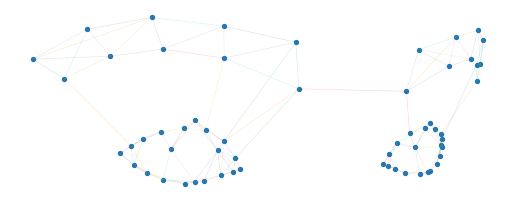

In [59]:
# Visualization helper
def plot_face_graph(
    graph, ax=None, title=None, node_size=8, edge_alpha=0.20, edge_width=0.4
):
    """Plot one face graph using its 2D normalized landmark coordinates."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))

    coords = graph.x.cpu().numpy()  # Nodes of the Graph
    edge_index = graph.edge_index.cpu().numpy()  # Edges of the Graph

    xy = coords[:, :2]

    seen = set()
    for i, j in edge_index.T:
        a, b = int(i), int(j)
        key = tuple(sorted((a, b)))
        if key in seen:
            continue
        seen.add(key)
        ax.plot(
            [xy[a, 0], xy[b, 0]],
            [xy[a, 1], xy[b, 1]],
            linewidth=edge_width,
            alpha=edge_alpha,
        )

    ax.scatter(xy[:, 0], xy[:, 1], s=node_size)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")

    if title is not None:
        ax.set_title(title)

    return ax


fig, ax = plt.subplots()
idx = random.randint(0, len(train_dataset) - 1)
graph = train_dataset[idx]
x, y = graph.x, graph.y
plot_face_graph(graph, ax)


# Understanding the samples
# 1) graph.x: (Num_nodes, 3) matrix. The coordinates (x1,x2,x3) of the facial landmarks, normalized to [-1,1]. Those are the node features of the graph.
# 2) graph.edge_index: (2, Num_edges) matrix. The edges of the graph, where each column (i,j) represents an edge from node i to node j.
# 3) graph.y: The label of the graph, where 0 means "alert" and 1 means "drowsy". This is the target variable we want to predict.
# 4) You can safely ignore the other 2 attributes of the graph (source_index and eye_openness) for this assignment.
# For completeness, eye_openness is a score in [0,1] that indicates how open the eyes are, and source_index is an index corresponding to the sample index with respect to the original dataset before graph construction.

In [60]:
print("Number of training samples:", len(train_dataset))
print("Number of test samples:", len(test_dataset))
print("Class mapping:", class_to_id)

sample = train_dataset[0]

print("\nSingle graph information:")
print(sample)
print("Node feature shape:", sample.x.shape)
print("Edge index shape:", sample.edge_index.shape)
print("Label:", sample.y)

Number of training samples: 400
Number of test samples: 100
Class mapping: {'awake': 0, 'drowsy': 1}

Single graph information:
Data(x=[60, 3], edge_index=[2, 304], y=[1], eye_openness=[1], source_index=[1])
Node feature shape: torch.Size([60, 3])
Edge index shape: torch.Size([2, 304])
Label: tensor([1])


In [61]:
from torch_geometric.loader import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

batch = next(iter(train_loader))

print(batch)
print("Combined node features:", batch.x.shape)
print("Combined edge index:", batch.edge_index.shape)
print("Graph labels:", batch.y.shape)
print("Batch vector:", batch.batch.shape)

DataBatch(x=[3840, 3], edge_index=[2, 19110], y=[64], eye_openness=[64], source_index=[64], batch=[3840], ptr=[65])
Combined node features: torch.Size([3840, 3])
Combined edge index: torch.Size([2, 19110])
Graph labels: torch.Size([64])
Batch vector: torch.Size([3840])


In [62]:
class GCNLayer(nn.Module):
    """
    Graph Convolutional Network layer implemented from scratch.

    Each node aggregates normalized messages from its neighbors and itself.
    """

    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x, edge_index):
        """
        Parameters
        ----------
        x : Tensor
            Node feature matrix with shape [num_nodes, in_features].

        edge_index : Tensor
            Edge list with shape [2, num_edges].
            Each column represents a directed edge: source -> destination.

        Returns
        -------
        Tensor
            Updated node representations with shape
            [num_nodes, out_features].
        """
        num_nodes = x.size(0)
        device = x.device

        source_nodes = edge_index[0]
        target_nodes = edge_index[1]

        # Add self-loops: every node also sends a message to itself.
        self_loops = torch.arange(num_nodes, device=device)

        source_nodes = torch.cat([source_nodes, self_loops])
        target_nodes = torch.cat([target_nodes, self_loops])

        # Compute the degree of each target node.
        degree = torch.zeros(num_nodes, device=device)
        degree.index_add_(
            0,
            target_nodes,
            torch.ones_like(target_nodes, dtype=torch.float)
        )

        # Symmetric normalization:
        # 1 / sqrt(deg(source) * deg(target))
        degree_inv_sqrt = degree.clamp(min=1).pow(-0.5)

        normalization = (
            degree_inv_sqrt[source_nodes]
            * degree_inv_sqrt[target_nodes]
        )

        # Create messages from source nodes.
        messages = x[source_nodes] * normalization.unsqueeze(1)

        # Aggregate messages at each target node.b
        aggregated = torch.zeros_like(x)
        aggregated.index_add_(0, target_nodes, messages)

        # Apply a trainable linear transformation.
        return self.linear(aggregated)

In [63]:
def global_mean_pool_from_scratch(node_embeddings, batch_index):
    """
    Convert node-level embeddings into graph-level embeddings
    by averaging all node embeddings within each graph.

    Parameters
    ----------
    node_embeddings : Tensor
        Shape [total_num_nodes, hidden_dim].

    batch_index : Tensor
        Shape [total_num_nodes].
        batch_index[i] indicates which graph node i belongs to.

    Returns
    -------
    Tensor
        Graph embeddings with shape [num_graphs, hidden_dim].
    """
    num_graphs = int(batch_index.max().item()) + 1
    hidden_dim = node_embeddings.size(1)

    pooled = torch.zeros(
        num_graphs,
        hidden_dim,
        device=node_embeddings.device
    )

    pooled.index_add_(0, batch_index, node_embeddings)

    node_counts = torch.zeros(
        num_graphs,
        device=node_embeddings.device
    )

    node_counts.index_add_(
        0,
        batch_index,
        torch.ones_like(batch_index, dtype=torch.float)
    )

    pooled = pooled / node_counts.clamp(min=1).unsqueeze(1)

    return pooled

In [64]:
class DrowsinessGCN(nn.Module):
    """
    From-scratch GCN for graph-level driver drowsiness classification.
    """

    def __init__(
        self,
        input_dim=3,
        hidden_dim=64,
        num_classes=2,
        dropout_rate=0.20
    ):
        super().__init__()

        self.gcn1 = GCNLayer(input_dim, hidden_dim)
        self.gcn2 = GCNLayer(hidden_dim, hidden_dim)

        self.dropout = nn.Dropout(dropout_rate)

        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, batch_index):
        # First graph-convolution layer
        x = self.gcn1(x, edge_index)
        x = torch.relu(x)
        x = self.dropout(x)

        # Second graph-convolution layer
        x = self.gcn2(x, edge_index)
        x = torch.relu(x)

        # Convert node embeddings into graph embeddings
        graph_embeddings = global_mean_pool_from_scratch(
            x,
            batch_index
        )

        # Two logits: awake and drowsy
        logits = self.classifier(graph_embeddings)

        return logits

In [65]:
model = DrowsinessGCN(
    input_dim=3,
    hidden_dim=64,
    num_classes=2,
    dropout_rate=0.20
).to(DEVICE)

print(model)
print("Device:", DEVICE)

DrowsinessGCN(
  (gcn1): GCNLayer(
    (linear): Linear(in_features=3, out_features=64, bias=True)
  )
  (gcn2): GCNLayer(
    (linear): Linear(in_features=64, out_features=64, bias=True)
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)
Device: cpu


In [66]:
batch = next(iter(train_loader))
batch = batch.to(DEVICE)

logits = model(
    x=batch.x.float(),
    edge_index=batch.edge_index.long(),
    batch_index=batch.batch.long()
)

print("Logits shape:", logits.shape)
print("Label shape:", batch.y.view(-1).shape)
print("First few logits:")
print(logits[:5])

Logits shape: torch.Size([64, 2])
Label shape: torch.Size([64])
First few logits:
tensor([[-0.1574,  0.0031],
        [-0.1382,  0.0219],
        [-0.1596, -0.0022],
        [-0.1338,  0.0255],
        [-0.1365,  0.0244]], grad_fn=<SliceBackward0>)


In [67]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    total_samples = 0

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()

        logits = model(
            x=batch.x.float(),
            edge_index=batch.edge_index.long(),
            batch_index=batch.batch.long()
        )

        labels = batch.y.view(-1).long()

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    for batch in loader:
        batch = batch.to(device)

        logits = model(
            x=batch.x.float(),
            edge_index=batch.edge_index.long(),
            batch_index=batch.batch.long()
        )

        labels = batch.y.view(-1).long()

        loss = criterion(logits, labels)

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples

In [68]:
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 100

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

train_losses = []
test_losses = []

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=DEVICE
    )

    test_loss = evaluate_loss(
        model=model,
        loader=test_loader,
        criterion=criterion,
        device=DEVICE
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d}/{NUM_EPOCHS} | "
            f"Train loss: {train_loss:.4f} | "
            f"Test loss: {test_loss:.4f}"
        )

Epoch 001/100 | Train loss: 0.6965 | Test loss: 0.6937
Epoch 010/100 | Train loss: 0.6823 | Test loss: 0.6875
Epoch 020/100 | Train loss: 0.6444 | Test loss: 0.6784
Epoch 030/100 | Train loss: 0.5933 | Test loss: 0.6804
Epoch 040/100 | Train loss: 0.5613 | Test loss: 0.6903
Epoch 050/100 | Train loss: 0.5475 | Test loss: 0.6962
Epoch 060/100 | Train loss: 0.5392 | Test loss: 0.6960
Epoch 070/100 | Train loss: 0.5291 | Test loss: 0.6794
Epoch 080/100 | Train loss: 0.5205 | Test loss: 0.6631
Epoch 090/100 | Train loss: 0.5139 | Test loss: 0.6800
Epoch 100/100 | Train loss: 0.5106 | Test loss: 0.6433


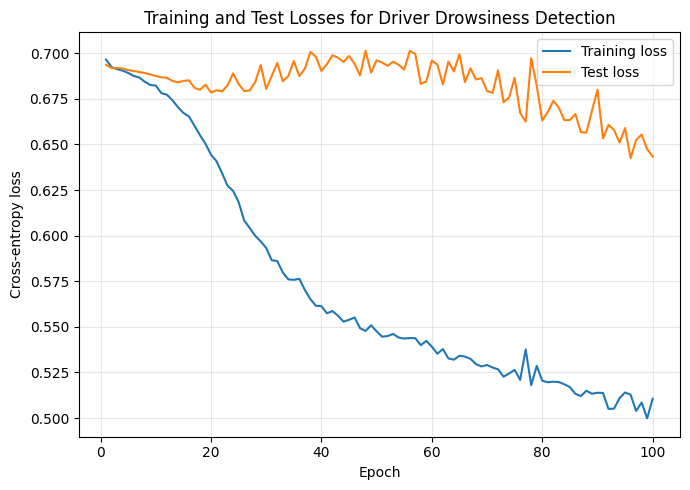

In [70]:
plt.figure(figsize=(7, 5))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    train_losses,
    label="Training loss"
)

plt.plot(
    range(1, NUM_EPOCHS + 1),
    test_losses,
    label="Test loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training and Test Losses for Driver Drowsiness Detection")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [71]:
@torch.no_grad()
def evaluate_precision_recall(model, loader, device, positive_class=1):
    model.eval()

    all_labels = []
    all_predictions = []

    for batch in loader:
        batch = batch.to(device)

        logits = model(
            x=batch.x.float(),
            edge_index=batch.edge_index.long(),
            batch_index=batch.batch.long()
        )

        predictions = logits.argmax(dim=1)
        labels = batch.y.view(-1).long()

        all_labels.append(labels.cpu())
        all_predictions.append(predictions.cpu())

    all_labels = torch.cat(all_labels)
    all_predictions = torch.cat(all_predictions)

    true_positive = (
        (all_labels == positive_class)
        & (all_predictions == positive_class)
    ).sum().item()

    false_negative = (
        (all_labels == positive_class)
        & (all_predictions != positive_class)
    ).sum().item()

    false_positive = (
        (all_labels != positive_class)
        & (all_predictions == positive_class)
    ).sum().item()

    true_negative = (
        (all_labels != positive_class)
        & (all_predictions != positive_class)
    ).sum().item()

    recall = true_positive / max(true_positive + false_negative, 1)
    precision = true_positive / max(true_positive + false_positive, 1)

    results = {
        "true_positive": true_positive,
        "false_negative": false_negative,
        "false_positive": false_positive,
        "true_negative": true_negative,
        "recall": recall,
        "precision": precision,
    }

    return results

In [72]:
results = evaluate_precision_recall(
    model=model,
    loader=test_loader,
    device=DEVICE,
    positive_class=1
)

print("Confusion-matrix components:")
print("TP:", results["true_positive"])
print("FN:", results["false_negative"])
print("FP:", results["false_positive"])
print("TN:", results["true_negative"])

print("\nFinal test metrics:")
print(f"Recall:    {results['recall']:.4f}")
print(f"Precision: {results['precision']:.4f}")

Confusion-matrix components:
TP: 31
FN: 19
FP: 15
TN: 35

Final test metrics:
Recall:    0.6200
Precision: 0.6739


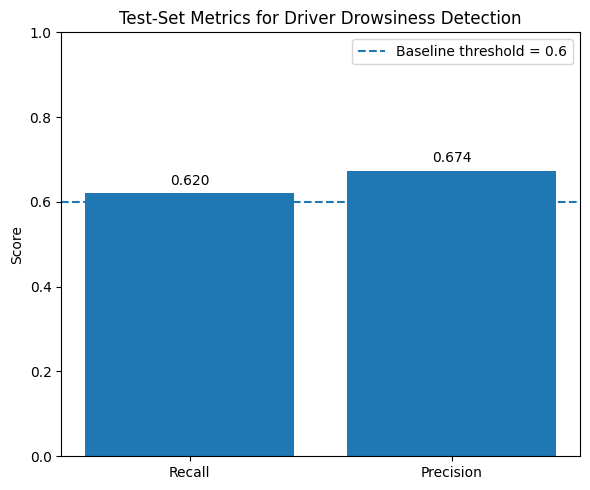

In [73]:
metric_names = ["Recall", "Precision"]

metric_values = [
    results["recall"],
    results["precision"]
]

plt.figure(figsize=(6, 5))

bars = plt.bar(metric_names, metric_values)

plt.axhline(
    y=0.6,
    linestyle="--",
    label="Baseline threshold = 0.6"
)

plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Test-Set Metrics for Driver Drowsiness Detection")
plt.legend()

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [56]:
recall = results["recall"]
precision = results["precision"]

if recall >= 0.6 and precision >= 0.6:
    print("Baseline requirement satisfied.")
else:
    print("Baseline requirement NOT satisfied.")
    print("Both recall and precision must be at least 0.6.")

Baseline requirement satisfied.


# Task 2

In [ ]:
class _BaseImageClassificationDataset(Dataset):
    """
    Base dataset for image classification datasets stored as:

        dataset_dir/
            class_to_id.json
            id_to_class.json
            train/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
            test/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
    """

    def __init__(
        self,
        dataset_dir,
        split="train",
        img_transform=None,
    ):
        super().__init__()
        self.dataset_dir = Path(dataset_dir)
        self.split = split
        self.img_transform = img_transform

        if self.split not in {"train", "test"}:
            raise ValueError(f"split must be 'train' or 'test', got: {self.split}")

        self.split_dir = self.dataset_dir / self.split
        self.labels_path = self.split_dir / "labels.csv"
        self.class_to_id_path = self.dataset_dir / "class_to_id.json"
        self.id_to_class_path = self.dataset_dir / "id_to_class.json"

        if not self.dataset_dir.exists():
            raise FileNotFoundError(f"Dataset directory not found: {self.dataset_dir}")
        if not self.split_dir.exists():
            raise FileNotFoundError(f"Split directory not found: {self.split_dir}")
        if not self.labels_path.exists():
            raise FileNotFoundError(f"labels.csv not found: {self.labels_path}")
        if not self.class_to_id_path.exists():
            raise FileNotFoundError(
                f"class_to_id.json not found: {self.class_to_id_path}"
            )
        if not self.id_to_class_path.exists():
            raise FileNotFoundError(
                f"id_to_class.json not found: {self.id_to_class_path}"
            )

        with open(self.class_to_id_path, "r") as fp:
            self.class_to_id = json.load(fp)

        with open(self.id_to_class_path, "r") as fp:
            self.id_to_class = json.load(fp)

        # Normalize keys for convenience
        self.id_to_class = {int(k): v for k, v in self.id_to_class.items()}
        self.num_classes = len(self.class_to_id)
        self.classes = [self.id_to_class[i] for i in range(self.num_classes)]

        self.labels = (
            pd.read_csv(self.labels_path, header=None).iloc[:, 0].astype(int).tolist()
        )

        self.img_paths = sorted(
            [
                p
                for p in self.split_dir.iterdir()
                if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
            ],
            key=lambda p: p.name,
        )

        if len(self.img_paths) != len(self.labels):
            raise ValueError(
                f"Mismatch between number of images ({len(self.img_paths)}) and "
                f"labels ({len(self.labels)}) in split '{self.split}'."
            )

    def __len__(self):
        return len(self.labels)

    def _load_image(self, img_path):
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.img_transform is not None:
                img = self.img_transform(img)
            return img

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = self._load_image(img_path)
        label = self.labels[idx]

        return image, label


class BDDObjectClassificationDataset(_BaseImageClassificationDataset):
    """
    Dataset for the cropped-object classification dataset.

    Returns:
        image, label
    or:
        image, label, metadata   (if return_metadata=True)

    Notes:
        - img_transform defaults to None.
        - The user is responsible for resizing / tensor conversion.
    """

    pass


class PatchShuffle:
    def __init__(self, patch_size=8):
        self.p = patch_size

    def __call__(self, img):
        # Input: [C, H, W]
        c, h, w = img.shape
        p = self.p

        # 1. Unfold image into patches [C, H/p, W/p, p, p]
        patches = img.unfold(1, p, p).unfold(2, p, p)
        num_h = h // p
        num_w = w // p

        # 2. Reshape to [num_patches, C, p, p]
        patches = patches.contiguous().view(c, -1, p, p).permute(1, 0, 2, 3)

        # 3. Shuffle the patches along the first dimension
        idx = torch.randperm(patches.size(0))
        patches = patches[idx]

        # 4. Reshape back to original image dimensions
        # We need to rearrange from [num_h*num_w, C, p, p] back to [C, H, W]
        patches = patches.view(num_h, num_w, c, p, p).permute(2, 0, 3, 1, 4)
        shuffled_img = patches.contiguous().view(c, h, w)

        return shuffled_img

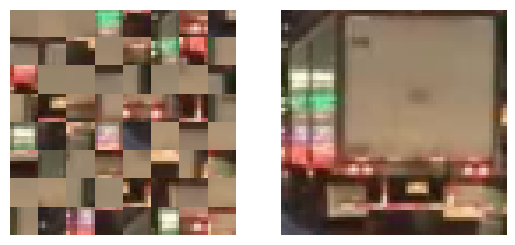

In [45]:
train_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=None,  # Fill train image transforms
)

test_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=None,  # Fill test image transforms
)

### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###
from torchvision.transforms import Compose, ToTensor, Resize
from torchvision.transforms import functional as vf
import matplotlib.pyplot as plt

vis_dataset_noisy = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor(), PatchShuffle(patch_size=8)]),
)
vis_dataset_clean = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor()]),
)
fig, ax = plt.subplots(1, 2)
img_noisy, label = vis_dataset_noisy[16]
img_clean, label = vis_dataset_clean[16]
ax[0].imshow(vf.to_pil_image(img_noisy))
ax[1].imshow(vf.to_pil_image(img_clean))
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_frame_on(False)
### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###

## Task 3 

In [ ]:
# This utility class is aimed to help you a bit with the linear probe classifier.
# You can choose whether to implement it or not!


class LinearProbeClassifier(nn.Module):
    """
    Frozen pretrained backbone + trainable linear classification head.

    TODO:
    - load a pretrained backbone,
    - remove/replace its original classification head (if any),
    - freeze the backbone parameters,
    - add a new trainable linear head for the BDD classes.
    """

    def __init__(self, backbone_arch: str, num_classes: int):
        super().__init__()
        self.backbone = None  # Here you can use a function that creates the backbone model based on the backbone_arch string (take a look here: https://docs.pytorch.org/vision/main/models.html)

        # TODO: Sometimes the pretrained backbone may already have a classification head (e.g. ResNet's fc layer, ViT's heads layer). In this case you might need to replace it with an Identity layer to get the features before the head.
        # The Identity layer is simply a placeholder for the Identity function, which returns its input unchanged.

        # TODO: freeze all pretrained backbone parameters. Freezing a parameter means that it will not be updated during gradient updates.

        # TODO: define the trainable linear classification head
        self.linear_head = None

    def forward(self, x: torch.Tensor):
        # The backbone should be used as a feature extractor.

        # Then the features from the backbone are passed through the linear head to get the final logits for classification.
        pass